# CatBoost Ensemble Version 1


In [1]:
import os
import numpy as np
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import time 
import sys
sys.path.append("..")
from utils.metrics import evaluate, compare_splits

SEED = 67
np.random.seed(SEED)

In [2]:
FEAT_PATH  = "../features/ensemble"
MODEL_PATH = "../models"

os.makedirs(MODEL_PATH, exist_ok=True)

# Loading Data

In [3]:
X_train = np.load(os.path.join(FEAT_PATH, "X_train.npy"))
X_val   = np.load(os.path.join(FEAT_PATH, "X_val.npy"))
X_test  = np.load(os.path.join(FEAT_PATH, "X_test.npy"))

y_train = np.load(os.path.join(FEAT_PATH, "y_train.npy"))
y_val   = np.load(os.path.join(FEAT_PATH, "y_val.npy"))
y_test  = np.load(os.path.join(FEAT_PATH, "y_test.npy"))

print("Feature shapes:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"  Classes : {len(np.unique(y_train))}")

Feature shapes:
  X_train : (65891, 2400)   y_train : (65891,)
  X_val   : (4380, 2400)    y_val   : (4380,)
  X_test  : (17596, 2400)   y_test  : (17596,)
  Classes : 38


In [4]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_val   = scaler.transform(X_val)        
X_test  = scaler.transform(X_test)       

joblib.dump(scaler, os.path.join(MODEL_PATH, "ensemble_scaler.pkl"))
print("Scaler saved")
print(f"X_train mean~0: {X_train.mean():.4f}  std~1: {X_train.std():.4f}")

Scaler saved
X_train mean~0: 0.0000  std~1: 1.0000


# Model Training

In [5]:
model = CatBoostClassifier(iterations= 1000,learning_rate= 0.06,depth= 6,loss_function= "MultiClass",border_count = 128,
    l2_leaf_reg=3,eval_metric= "Accuracy",random_seed= SEED,early_stopping_rounds= 50,verbose= 50,task_type="GPU",devices="0")

start=time.time()

model.fit(X_train, y_train,eval_set=(X_val, y_val),use_best_model=True)

t=time.time()-start

print("\nBest iteration:", model.get_best_iteration())
print(f"Total Time Taken : {t:.2f}s")

0:	learn: 0.2799017	test: 0.2716895	best: 0.2716895 (0)	total: 589ms	remaining: 9m 47s
50:	learn: 0.8628189	test: 0.8456621	best: 0.8456621 (50)	total: 25.3s	remaining: 7m 50s
100:	learn: 0.9245876	test: 0.9061644	best: 0.9061644 (100)	total: 50.2s	remaining: 7m 26s
150:	learn: 0.9505395	test: 0.9305936	best: 0.9305936 (150)	total: 1m 14s	remaining: 7m
200:	learn: 0.9636521	test: 0.9401826	best: 0.9401826 (200)	total: 1m 38s	remaining: 6m 32s
250:	learn: 0.9723483	test: 0.9479452	best: 0.9481735 (244)	total: 2m 1s	remaining: 6m 2s
300:	learn: 0.9773565	test: 0.9522831	best: 0.9525114 (297)	total: 2m 23s	remaining: 5m 33s
350:	learn: 0.9805892	test: 0.9550228	best: 0.9561644 (340)	total: 2m 44s	remaining: 5m 4s
400:	learn: 0.9835941	test: 0.9579909	best: 0.9584475 (398)	total: 3m 5s	remaining: 4m 37s
450:	learn: 0.9859010	test: 0.9598174	best: 0.9600457 (423)	total: 3m 26s	remaining: 4m 11s
500:	learn: 0.9880712	test: 0.9618721	best: 0.9627854 (490)	total: 3m 46s	remaining: 3m 45s
550:	

In [6]:
model_file = os.path.join(MODEL_PATH, "catboost_ensemble.cbm")
model.save_model(model_file)
print("Model saved :", model_file)

Model saved : ../models/catboost_ensemble.cbm


# Model Evaluation

TRAINING DATA

===== METRICS =====


Metrics,Value
Accuracy,0.996403
Precision,0.996389
Recall,0.996407
F1_Score,0.996395
ROC_AUC,0.999994
Log_loss,0.060556



============================ CONFUSION MATRIX =============================


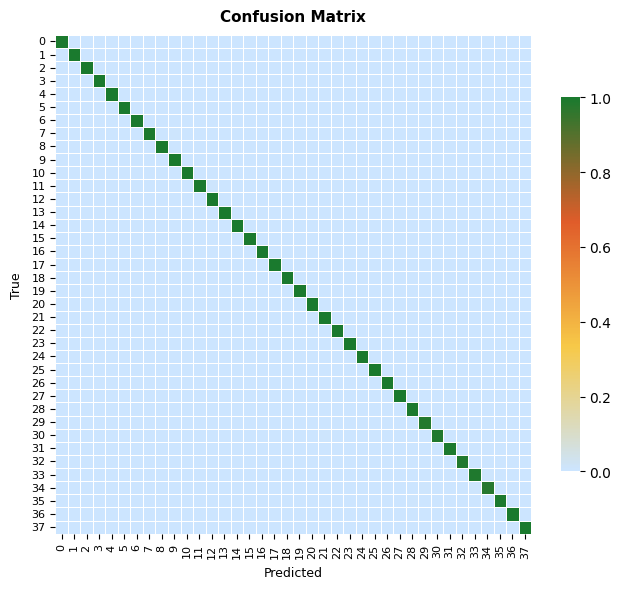


==================================== ROC CURVE ====================================


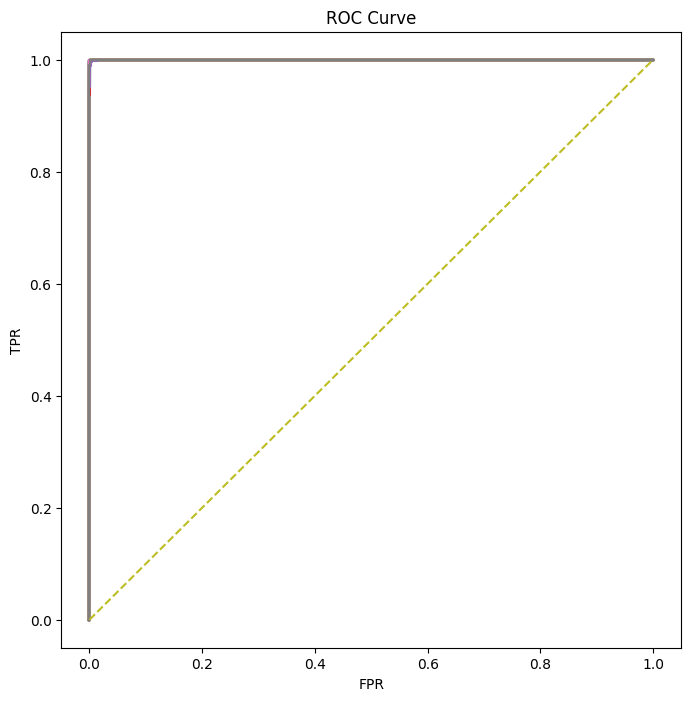

In [7]:
print("TRAINING DATA")
train_pred  = model.predict(X_train).flatten().astype(int)
train_proba = model.predict_proba(X_train)
train_metrics = evaluate(y_train, train_pred, train_proba)

VALIDATION DATA

===== METRICS =====


Metrics,Value
Accuracy,0.973973
Precision,0.974221
Recall,0.973803
F1_Score,0.973885
ROC_AUC,0.999782
Log_loss,0.120105



============================ CONFUSION MATRIX =============================


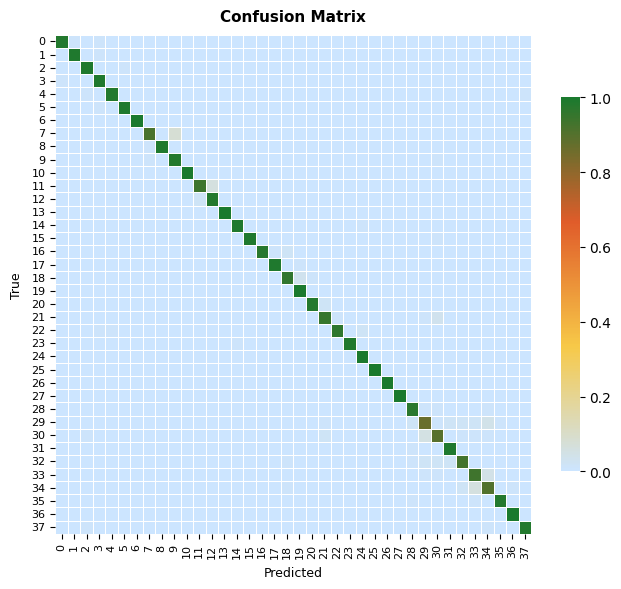


==================================== ROC CURVE ====================================


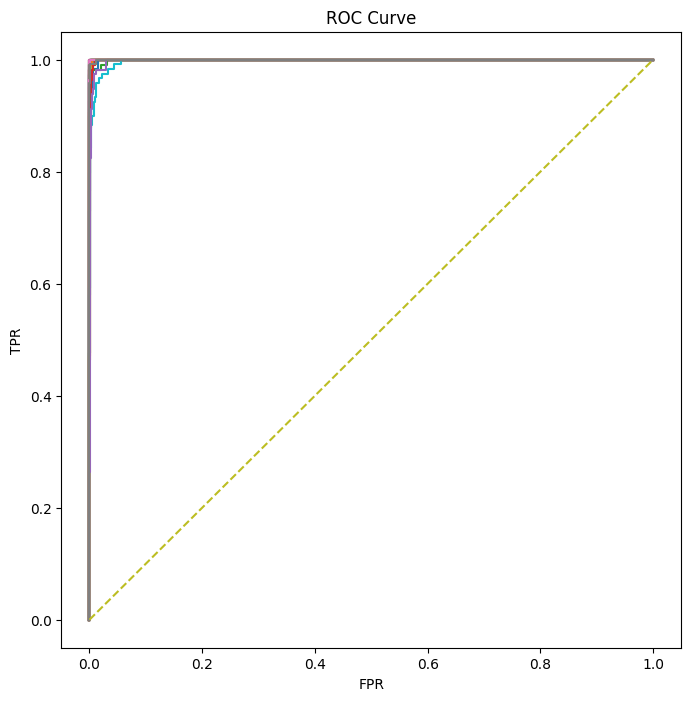

In [8]:
print("VALIDATION DATA")
val_pred  = model.predict(X_val).flatten().astype(int)
val_proba = model.predict_proba(X_val)
val_metrics = evaluate(y_val, val_pred, val_proba)

TESTING DATA

===== METRICS =====


Metrics,Value
Accuracy,0.973119
Precision,0.973287
Recall,0.972848
F1_Score,0.972962
ROC_AUC,0.999814
Log_loss,0.116144



============================ CONFUSION MATRIX =============================


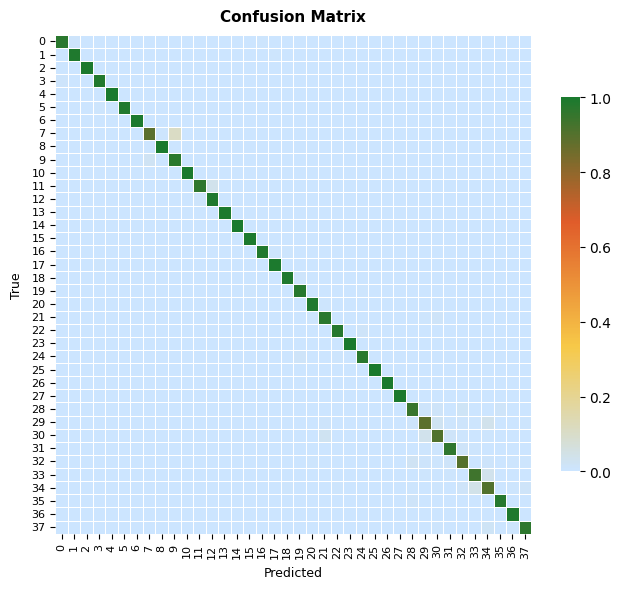


==================================== ROC CURVE ====================================


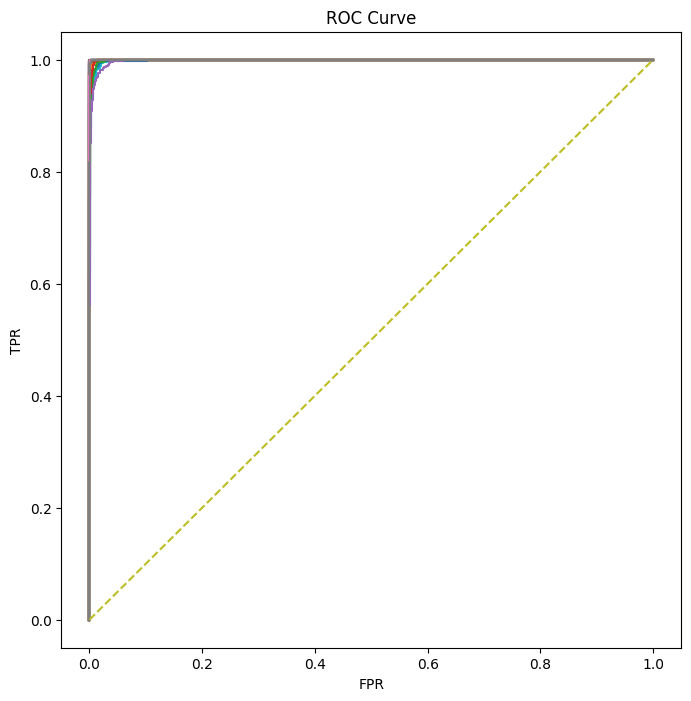

In [9]:
print("TESTING DATA")
test_pred  = model.predict(X_test).flatten().astype(int)
test_proba = model.predict_proba(X_test)
test_metrics = evaluate(y_test, test_pred, test_proba)


================ SPLIT COMPARISON ================


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Log_loss
train,0.9964,0.9964,0.9964,0.9964,1.0000,0.0606
val,0.9740,0.9742,0.9738,0.9739,0.9998,0.1201
test,0.9731,0.9733,0.9728,0.9730,0.9998,0.1161


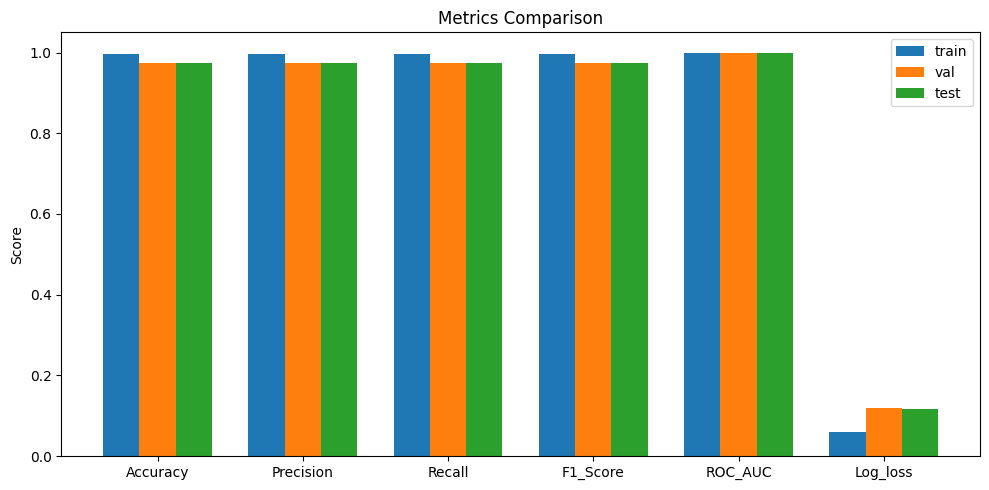

In [10]:
df_comparison = compare_splits(train_metrics, val_metrics, test_metrics)

## Feature Importance

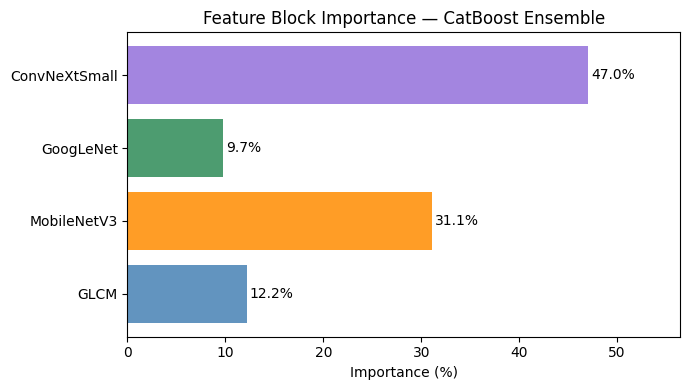

Block importance:
  GLCM           : 12.18%
  MobileNetV3    : 31.05%
  GoogLeNet      : 9.75%
  ConvNeXtSmall  : 47.02%


In [11]:
import matplotlib.pyplot as plt

importances = model.get_feature_importance()

dims = {"GLCM": 32, "MobileNetV3": 576, "GoogLeNet": 1024, "ConvNeXtSmall": 768}

block_importance = {}
start = 0
for name, dim in dims.items():
    block_importance[name] = importances[start:start + dim].sum()
    start += dim

total   = sum(block_importance.values())
block_pct = {k: (v / total) * 100 for k, v in block_importance.items()}

plt.figure(figsize=(7, 4))
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]
bars = plt.barh(list(block_pct.keys()), list(block_pct.values()), color=colors, alpha=0.85)

plt.xlabel("Importance (%)")
plt.title("Feature Block Importance — CatBoost Ensemble")
plt.xlim(0, max(block_pct.values()) * 1.2)

for bar, val in zip(bars, block_pct.values()):
    plt.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Block importance:")
for k, v in block_pct.items():
    print(f"  {k:<15}: {v:.2f}%")